In [5]:
#-----Installation des packages et importation des modules------

!pip -q install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime
from matplotlib import pyplot as plt

In [11]:
#-----Importation des données via biblio YahooFinance------

def get_data_yf(ticker, name):

    df = yf.download(ticker, period="max")
    df= df.reset_index()  # remettre la date comme colonne

    df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

    # Renommer les colonnes pour avoir un dataset propre
    df = df.rename(columns={
        "Date": "timestamp",
        "Open": f"{name}_open",
        "High": f"{name}_high",
        "Low": f"{name}_low",
        "Close": f"{name}_price",
        "Volume": f"{name}_volume"
    })

    # On garde uniquement les colonnes utiles
    df = df[["timestamp",
             f"{name}_price",
             f"{name}_volume",
             f"{name}_open",
             f"{name}_high",
             f"{name}_low"]]

    return df

yf_series = [

    # Cryptos
    ("BTC-USD", "BTC"),
    ("ETH-USD", "ETH"),

    # Stock market
    ("^GSPC", "SP500"),
    ("^IXIC", "NASDAQ"),

    # Metals
    ("ALI=F", "ALUMINUM"),
    ("GC=F", "GOLD"),
    ("SI=F", "SILVER"),
    ("HG=F", "COPPER"),
]

btc_df = get_data_yf("BTC-USD", "BTC")
eth_df = get_data_yf("ETH-USD", "ETH")

df_yf = pd.merge(btc_df, eth_df, on='timestamp', how='inner')

for var in yf_series[2:]:
    var_df = get_data_yf(var[0], var[1])
    df_yf = df_yf.merge(var_df, on="timestamp", how="inner")

/tmp/ipykernel_2382/53915762.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="max")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2382/53915762.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="max")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2382/53915762.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="max")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2382/53915762.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="max")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2382/53915762.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to 

,timestamp,BTC_price,BTC_volume,BTC_open,BTC_high,BTC_low,ETH_price,ETH_volume,ETH_open,ETH_high,...,SILVER_price,SILVER_volume,SILVER_open,SILVER_high,SILVER_low,COPPER_price,COPPER_volume,COPPER_open,COPPER_high,COPPER_low
0,2017-11-09,7143.580078,3226249984,7446.830078,7446.830078,7101.520020,320.884003,893249984,308.644989,329.451996,...,16.943001,2,16.930000,16.943001,16.930000,3.0800,222,3.0775,3.0855,3.0770
1,2017-11-10,6618.140137,5208249856,7173.729980,7312.000000,6436.870117,299.252991,885985984,320.670990,324.717987,...,16.844000,1,17.000000,17.000000,16.844000,3.0695,214,3.0790,3.0790,3.0635
2,2017-11-13,6559.490234,6263249920,5938.250000,6811.189941,5844.290039,316.716003,1041889984,307.024994,328.415009,...,17.023001,3,16.840000,17.023001,16.840000,3.1115,368,3.0860,3.1260,3.0860
3,2017-11-14,6635.750000,3197110016,6561.479980,6764.979980,6461.750000,337.631012,1069680000,316.763000,340.177002,...,17.052000,1,16.905001,17.052000,16.905001,3.0600,289,3.1030,3.1030,3.0450
4,2017-11-15,7315.540039,4200880128,6634.759766,7342.250000,6634.759766,333.356995,722665984,337.963989,340.911987,...,16.950001,1,16.950001,16.950001,16.940001,3.0490,338,3.0505,3.0575,3.0335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2033,2025-12-15,86419.781250,45559514323,88171.078125,89983.921875,85304.078125,2964.183105,28765976892,3060.481445,3175.118164,...,62.939999,387,61.230000,62.950001,61.230000,5.3385,1068,5.2735,5.4100,5.2735
2034,2025-12-16,87843.984375,41262178223,86424.406250,88170.093750,85381.687500,2964.180908,22709189818,2964.379639,2978.921387,...,62.700001,70,62.665001,63.000000,62.540001,5.2870,798,5.2700,5.3060,5.2700
2035,2025-12-17,86143.757812,44243392914,87847.617188,90264.570312,85316.265625,2831.403564,26159825528,2964.019531,3025.815430,...,66.237000,233,65.279999,66.474998,65.089996,5.3635,1289,5.3150,5.3680,5.3150
2036,2025-12-18,85462.507812,52667115348,86144.367188,89412.664062,84436.312500,2827.069092,29194181349,2831.488281,2994.552734,...,64.592003,118,65.775002,65.775002,64.279999,5.3665,860,5.3220,5.3860,5.3220


In [14]:
#------Nettoyage des données------

# Vérification et suppression des doublons
print("Doublons avant nettoyage :", df_yf.duplicated(subset="timestamp").sum())
df_yf = df_yf.drop_duplicates(subset="timestamp")

# Vérification des valeurs manquantes
print("Valeurs manquantes avant interpolation :\n", df_yf.isna().sum())

# Conversion du timestamp en datetime
df_yf["timestamp"] = pd.to_datetime(df_yf["timestamp"], errors="coerce")
df_yf = df_yf.sort_values("timestamp")

# Choix de l'interpolation linéaire pour prix et volume (et OHLC) (ici pas vrmt besoin car 0 valeurs manquantes)
cols_to_interpolate = [c for c in df_yf.columns if c != "timestamp"]
df_yf[cols_to_interpolate] = df_yf[cols_to_interpolate].apply(pd.to_numeric, errors="coerce")
df_yf[cols_to_interpolate] = df_yf[cols_to_interpolate].interpolate(method="linear")

# Vérification finale
print("Valeurs manquantes après interpolation :\n", df_yf.isna().sum())
print(df_yf.info())

Doublons avant nettoyage : 0
Valeurs manquantes avant interpolation :
 timestamp          0
BTC_price          0
BTC_volume         0
BTC_open           0
BTC_high           0
BTC_low            0
ETH_price          0
ETH_volume         0
ETH_open           0
ETH_high           0
ETH_low            0
SP500_price        0
SP500_volume       0
SP500_open         0
SP500_high         0
SP500_low          0
NASDAQ_price       0
NASDAQ_volume      0
NASDAQ_open        0
NASDAQ_high        0
NASDAQ_low         0
ALUMINUM_price     0
ALUMINUM_volume    0
ALUMINUM_open      0
ALUMINUM_high      0
ALUMINUM_low       0
GOLD_price         0
GOLD_volume        0
GOLD_open          0
GOLD_high          0
GOLD_low           0
SILVER_price       0
SILVER_volume      0
SILVER_open        0
SILVER_high        0
SILVER_low         0
COPPER_price       0
COPPER_volume      0
COPPER_open        0
COPPER_high        0
COPPER_low         0
dtype: int64
Valeurs manquantes après interpolation :
 timestamp    

In [15]:
#-----Création de nouvelles varaibles pour enrichir notre dataset et répondre à la problématique-----

df = df_yf.copy()

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.sort_values("timestamp").reset_index(drop=True)

for col in ["BTC", "ETH", "SP500", "NASDAQ"]:
    df[f"{col}_return_daily"] = np.log(df[f"{col}_price"] / df[f"{col}_price"].shift(1))

    if col in ["BTC", "ETH"]:
        # Volatilité rolling 7 jours
        df[f"{col}_volatility_7d"] = df[f"{col}_return_daily"].rolling(window=7).std()

        # Volatilité rolling 30 jours
        df[f"{col}_volatility_30d"] = df[f"{col}_return_daily"].rolling(window=30).std()

        # Moyenne mobile 7 jours
        df[f"{col}_moving_avg_7d"] = df[f"{col}_price"].rolling(window=7).mean()

        # Moyenne mobile 30 jours
        df[f"{col}_moving_avg_30d"] = df[f"{col}_price"].rolling(window=30).mean()

        # Range journalier (High - Low)
        df[f"{col}_range_daily"] = df[f"{col}_high"] - df[f"{col}_low"]

        # Variation journalière du volume
        df[f"{col}_volume_change"] = df[f"{col}_volume"].pct_change()

# Vérification des valeurs manquantes
print("Valeurs manquantes sur df:\n", df.isna().sum())

# Gérer tous les NaN du nouveau dataset
df_final = df.dropna().reset_index(drop=True)

# Vérification rapide des infos du dataset
print("Valeurs manquantes sur df_final :\n", df_final.isna().sum())
print(df_final.info())

Valeurs manquantes sur df:
 timestamp               0
BTC_price               0
BTC_volume              0
BTC_open                0
BTC_high                0
BTC_low                 0
ETH_price               0
ETH_volume              0
ETH_open                0
ETH_high                0
ETH_low                 0
SP500_price             0
SP500_volume            0
SP500_open              0
SP500_high              0
SP500_low               0
NASDAQ_price            0
NASDAQ_volume           0
NASDAQ_open             0
NASDAQ_high             0
NASDAQ_low              0
ALUMINUM_price          0
ALUMINUM_volume         0
ALUMINUM_open           0
ALUMINUM_high           0
ALUMINUM_low            0
GOLD_price              0
GOLD_volume             0
GOLD_open               0
GOLD_high               0
GOLD_low                0
SILVER_price            0
SILVER_volume           0
SILVER_open             0
SILVER_high             0
SILVER_low              0
COPPER_price            0
COPPER_vol

,timestamp,BTC_price,BTC_volume,BTC_open,BTC_high,BTC_low,ETH_price,ETH_volume,ETH_open,ETH_high,...,BTC_volume_change,ETH_return_daily,ETH_volatility_7d,ETH_volatility_30d,ETH_moving_avg_7d,ETH_moving_avg_30d,ETH_range_daily,ETH_volume_change,SP500_return_daily,NASDAQ_return_daily
0,2017-12-22,13831.799805,22197999616,15898.000000,15943.400391,11833.000000,674.859985,4977710080,822.643005,827.682983,...,0.343981,-1.960946e-01,0.102098,0.086628,759.534424,508.866338,283.920959,0.394684,-0.000458,-0.000776
1,2017-12-26,16099.799805,13454300160,14036.599609,16461.199219,14028.900391,773.835999,2201159936,763.369995,786.789978,...,-0.393896,1.368547e-01,0.115322,0.087064,770.680141,524.685772,25.854980,-0.557797,-0.001059,-0.003412
2,2017-12-27,15838.500000,12487600128,16163.500000,16930.900391,15114.299805,762.841980,2100029952,774.969971,789.252991,...,-0.071851,-1.430906e-02,0.115226,0.087325,781.879281,539.556638,50.839966,-0.045944,0.000791,0.000445
3,2017-12-28,14606.500000,12336499712,15864.099609,15888.400391,13937.299805,737.023010,2389149952,762.208008,763.318970,...,-0.012100,-3.443179e-02,0.099526,0.087824,773.647566,552.869704,62.131958,0.137674,0.001832,0.001558
4,2017-12-29,14656.200195,13025500160,14695.799805,15279.000000,14307.000000,753.591980,2648969984,740.388977,770.117004,...,0.055851,2.223197e-02,0.098262,0.087524,763.185992,566.877537,40.509033,0.108750,-0.005197,-0.006752
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2003,2025-12-15,86419.781250,45559514323,88171.078125,89983.921875,85304.078125,2964.183105,28765976892,3060.481445,3175.118164,...,-0.432463,-3.968194e-02,0.041315,0.045664,3154.506941,3158.179622,275.432373,0.179368,-0.001598,-0.005957
2004,2025-12-16,87843.984375,41262178223,86424.406250,88170.093750,85381.687500,2964.180908,22709189818,2964.379639,2978.921387,...,-0.094324,-7.412722e-07,0.039487,0.044392,3145.899519,3136.908716,88.909668,-0.210554,-0.002387,0.002341
2005,2025-12-17,86143.757812,44243392914,87847.617188,90264.570312,85316.265625,2831.403564,26159825528,2964.019531,3025.815430,...,0.072251,-4.582819e-02,0.038830,0.042212,3103.928885,3121.536353,234.481445,0.151949,-0.011660,-0.018258
2006,2025-12-18,85462.507812,52667115348,86144.367188,89412.664062,84436.312500,2827.069092,29194181349,2831.488281,2994.552734,...,0.190395,-1.532029e-03,0.022504,0.041377,3033.350900,3101.599618,217.433105,0.115993,0.007903,0.013700


In [16]:
corr_matrix = df_final[['BTC_return_daily','SP500_return_daily','NASDAQ_return_daily']].corr()
print(corr_matrix)

corr_matrix = df_final[['ETH_return_daily','SP500_return_daily','NASDAQ_return_daily']].corr()
print(corr_matrix)

corr_matrix = df_final[['ETH_return_daily','BTC_return_daily']].corr()
print(corr_matrix)

                     BTC_return_daily  SP500_return_daily  NASDAQ_return_daily
BTC_return_daily             1.000000            0.295697             0.312236
SP500_return_daily           0.295697            1.000000             0.950922
NASDAQ_return_daily          0.312236            0.950922             1.000000
                     ETH_return_daily  SP500_return_daily  NASDAQ_return_daily
ETH_return_daily             1.000000            0.322232             0.336790
SP500_return_daily           0.322232            1.000000             0.950922
NASDAQ_return_daily          0.336790            0.950922             1.000000
                  ETH_return_daily  BTC_return_daily
ETH_return_daily          1.000000          0.811293
BTC_return_daily          0.811293          1.000000


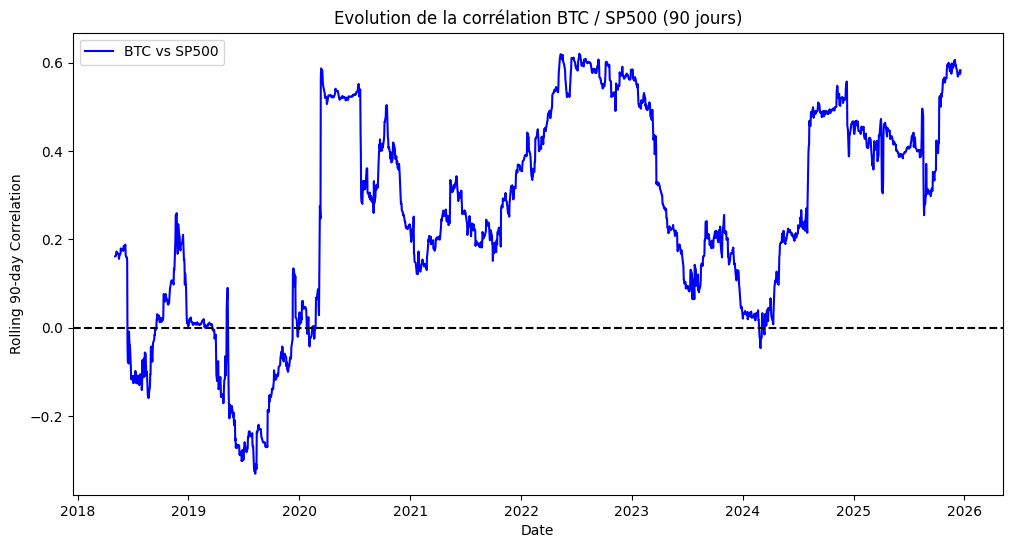

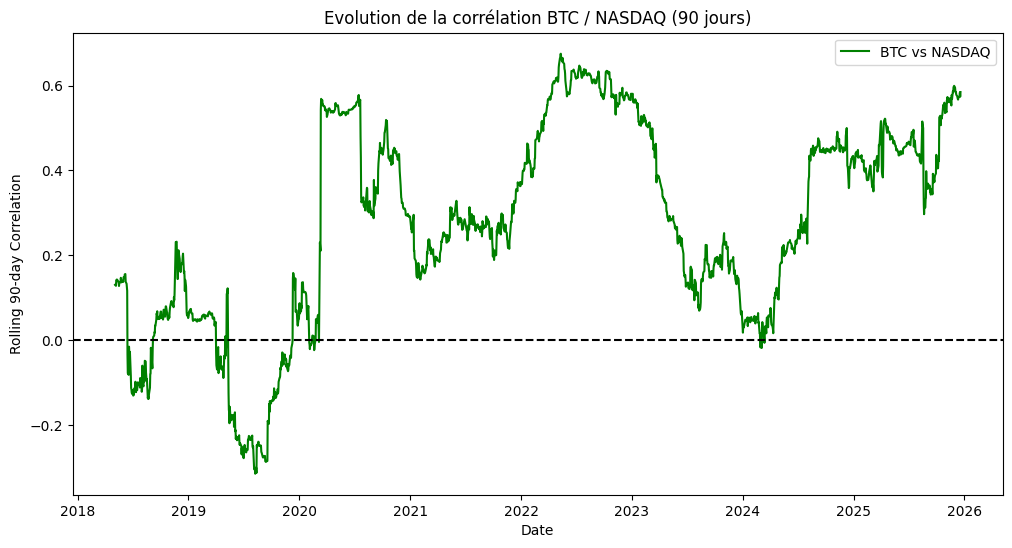

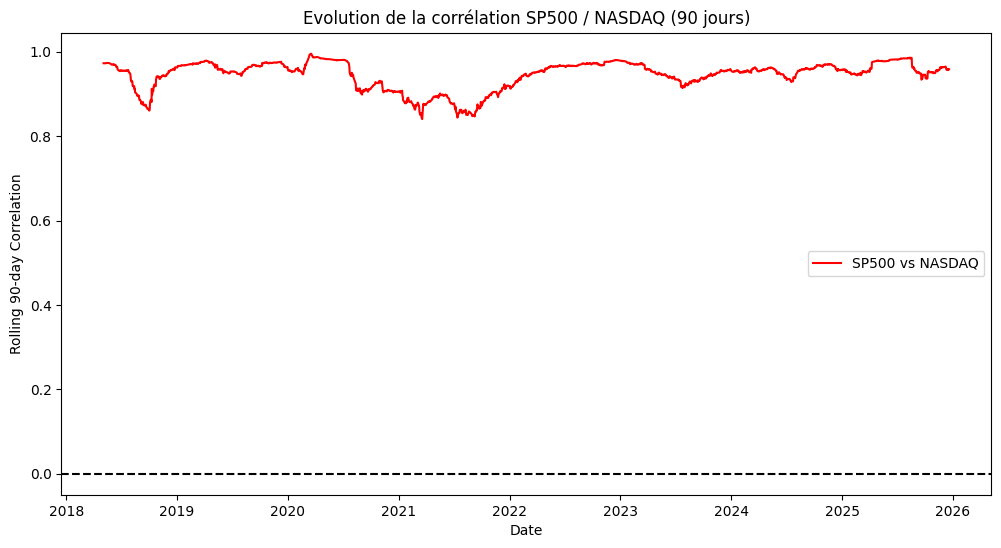

In [17]:
rolling_corr_SP500 = df_final['BTC_return_daily'].rolling(window=90).corr(df_final['SP500_return_daily'])
rolling_corr_NASDAQ = df_final['BTC_return_daily'].rolling(window=90).corr(df_final['NASDAQ_return_daily'])
rolling_corr_SP500_et_NASDAQ = df_final['SP500_return_daily'].rolling(window=90).corr(df_final['NASDAQ_return_daily'])

# Graphique BTC vs SP500
plt.figure(figsize=(12,6))
plt.plot(df_final['timestamp'], rolling_corr_SP500, label='BTC vs SP500', color='blue')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Rolling 90-day Correlation')
plt.title('Evolution de la corrélation BTC / SP500 (90 jours)')
plt.legend()
plt.show()

# Graphique BTC vs NASDAQ
plt.figure(figsize=(12,6))
plt.plot(df_final['timestamp'], rolling_corr_NASDAQ, label='BTC vs NASDAQ', color='green')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Rolling 90-day Correlation')
plt.title('Evolution de la corrélation BTC / NASDAQ (90 jours)')
plt.legend()
plt.show()

# Graphique SP500 vs NASDAQ
plt.figure(figsize=(12,6))
plt.plot(df_final['timestamp'], rolling_corr_SP500_et_NASDAQ, label='SP500 vs NASDAQ', color='red')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Rolling 90-day Correlation')
plt.title('Evolution de la corrélation SP500 / NASDAQ (90 jours)')
plt.legend()
plt.show()

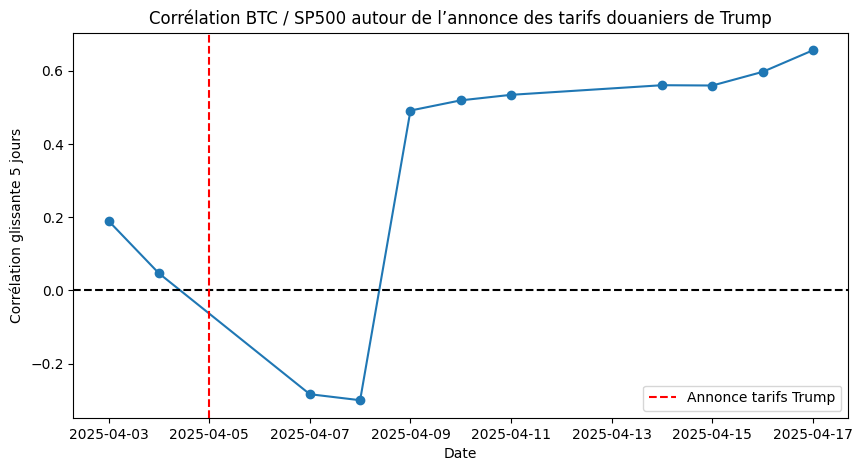

In [18]:
# Date de l'événement
event_date = pd.to_datetime('2025-04-05')

# Définir une fenêtre autour de l'événement, par ex. ±15 jours
window = 15
start_date = event_date - pd.Timedelta(days=window)
end_date = event_date + pd.Timedelta(days=window)

# Filtrer le dataset pour cette période
event_df = df_final[(df_final['timestamp'] >= start_date) & (df_final['timestamp'] <= end_date)]

# Calculer la corrélation glissante sur 5 jours autour de l'événement
rolling_corr_event = event_df['BTC_return_daily'].rolling(window=10).corr(event_df['SP500_return_daily'])

# Visualiser
plt.figure(figsize=(10,5))
plt.plot(event_df['timestamp'], rolling_corr_event, marker='o', linestyle='-')
plt.axhline(0, color='black', linestyle='--')
plt.axvline(event_date, color='red', linestyle='--', label='Annonce tarifs Trump')
plt.xlabel('Date')
plt.ylabel('Corrélation glissante 5 jours')
plt.title('Corrélation BTC / SP500 autour de l’annonce des tarifs douaniers de Trump')
plt.legend()
plt.show()

In [27]:
def get_data_fred(ticker, name, start_date = eth_df['timestamp'].min()):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={ticker}"
    df = pd.read_csv(url)
    date_col = df.columns[0]
    value_col = df.columns[1]
    df[date_col] = pd.to_datetime(df[date_col])
    df[value_col] = pd.to_numeric(df[value_col], errors = "coerce")
    df = df.rename(columns = {date_col: "timestamp", value_col: name})
    df = df[df["timestamp"] >= pd.to_datetime(start_date)]
    return df

fred_series = [
    # Energy market
    ("DCOILWTICO", "WTI"),              # WTI Oil
    ("DCOILBRENTEU", "BRENT"),          # Brent Oil
    ("DHHNGSP", "NATGAS"),              # Henry Hub Natural Gas
    ("DRGASLA", "RBOB"),                # RBOB Gasoline

    # US Bonds
    ("DGS3MO", "UST_3M"),               # Treasury 3-month yield
    ("DGS2", "UST_2Y"),                 # 2-year
    ("DGS5", "UST_5Y"),                 # 5-year
    ("DGS10", "UST_10Y"),               # 10-year
    ("DGS30", "UST_30Y"),               # 30-year
    ("DFII10", "TIPS10Y_REAL"),         # 10-year (real yield)

    # Monetary policy
    ("EFFR", "EFFR"),                   # Effective Federal Funds Rate
    ("DFEDTARU", "FED_TARGET_UPPER"),   # Upper bound of the Fed Funds target range
    ("BAMLH0A0HYM2", "HY_OAS"),         # ICE BofA US High Yield OAS 
    ("BAA10Y", "BAA_10Y_SPREAD"),       # Moody’s Baa corporate yield minus 10Y Treasury yield

    # Some index
    ("VIXCLS", "VIX"),                  # VIX
    ("DTWEXBGS", "USD_BROAD"),          # Broad trade-weighted U.S. dollar index
]

In [39]:
btc_df = get_data_yf("BTC-USD", "BTC")
eth_df = get_data_yf("ETH-USD", "ETH")

df_fred = pd.merge(btc_df, eth_df, on='timestamp', how='inner')

for var in fred_series:
    var_df = get_data_fred(var[0], var[1])
    df_fred = df_fred.merge(var_df, on="timestamp", how="inner")

/tmp/ipykernel_2382/53915762.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="max")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2382/53915762.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="max")
[*********************100%***********************]  1 of 1 completed


In [45]:
#------Nettoyage des données 2------

# Vérification et suppression des doublons
print("Duplicates before cleaning:", df_fred.duplicated(subset="timestamp").sum())
df_fred = df_fred.drop_duplicates(subset="timestamp")

# Conversion du timestamp en datetime
df_fred["timestamp"] = pd.to_datetime(df_fred["timestamp"], errors="coerce")
df_fred = df_fred.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

# Vérification des valeurs manquantes
print("Missing values before interpolation:\n", df_fred.isna().sum())

# 4) Conversion des colummes pas timestamp vers numerique
cols_to_interpolate = [c for c in df_fred.columns if c != "timestamp"]
df_fred[cols_to_interpolate] = df_fred[cols_to_interpolate].apply(pd.to_numeric, errors="coerce")

# 5) L'interpolation linéaire
df_fred = df_fred.set_index("timestamp")
df_fred[cols_to_interpolate] = df_fred[cols_to_interpolate].interpolate(
    method="time",
    limit_area="inside"   # no extrapolation at beginning/end
)
df_fred = df_fred.reset_index()

# Vérification finale
print("Missing values after interpolation:\n", df_fred.isna().sum())
print(df_fred.info())

Duplicates before cleaning: 0
Missing values before interpolation:
 timestamp           0
BTC_price           0
BTC_volume          0
BTC_open            0
BTC_high            0
BTC_low             0
ETH_price           0
ETH_volume          0
ETH_open            0
ETH_high            0
ETH_low             0
WTI                 0
BRENT               0
NATGAS              0
RBOB                0
UST_3M              0
UST_2Y              0
UST_5Y              0
UST_10Y             0
UST_30Y             0
TIPS10Y_REAL        0
EFFR                0
FED_TARGET_UPPER    0
HY_OAS              0
BAA_10Y_SPREAD      0
VIX                 0
USD_BROAD           0
dtype: int64
Missing values after interpolation:
 timestamp           0
BTC_price           0
BTC_volume          0
BTC_open            0
BTC_high            0
BTC_low             0
ETH_price           0
ETH_volume          0
ETH_open            0
ETH_high            0
ETH_low             0
WTI                 0
BRENT               0
NA

In [43]:
df_fred

,timestamp,BTC_price,BTC_volume,BTC_open,BTC_high,BTC_low,ETH_price,ETH_volume,ETH_open,ETH_high,...,UST_5Y,UST_10Y,UST_30Y,TIPS10Y_REAL,EFFR,FED_TARGET_UPPER,HY_OAS,BAA_10Y_SPREAD,VIX,USD_BROAD
0,2017-11-09,7143.580078,3226249984,7446.830078,7446.830078,7101.520020,320.884003,893249984,308.644989,329.451996,...,2.01,2.33,2.81,0.46,1.16,1.25,3.79,1.93,10.50,111.562600
1,2017-11-10,6618.140137,5208249856,7173.729980,7312.000000,6436.870117,299.252991,885985984,320.670990,324.717987,...,2.06,2.40,2.88,0.52,1.16,1.25,3.76,1.93,11.29,111.617775
2,2017-11-13,6559.490234,6263249920,5938.250000,6811.189941,5844.290039,316.716003,1041889984,307.024994,328.415009,...,2.08,2.40,2.87,0.52,1.16,1.25,3.77,1.93,11.50,111.783300
3,2017-11-14,6635.750000,3197110016,6561.479980,6764.979980,6461.750000,337.631012,1069680000,316.763000,340.177002,...,2.06,2.38,2.84,0.51,1.16,1.25,3.84,1.93,11.59,111.509700
4,2017-11-15,7315.540039,4200880128,6634.759766,7342.250000,6634.759766,333.356995,722665984,337.963989,340.911987,...,2.04,2.33,2.77,0.48,1.16,1.25,3.97,1.95,13.13,111.480900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2107,2025-12-08,90640.203125,57394099056,90424.585938,92267.117188,89644.890625,3125.197998,25262165670,3061.013672,3177.867676,...,3.75,4.17,4.81,1.91,3.89,4.00,2.89,1.73,16.66,121.147800
2108,2025-12-09,92691.710938,66861721440,90639.703125,94601.570312,89586.976562,3321.114990,32012553374,3124.942627,3395.838623,...,3.78,4.18,4.80,1.92,3.89,4.00,2.89,1.73,16.93,121.060100
2109,2025-12-10,92020.945312,65420694513,92695.234375,94477.156250,91640.132812,3325.390137,30694387989,3321.204102,3446.622803,...,3.72,4.13,4.78,1.88,3.89,4.00,2.91,1.76,15.77,121.055700
2110,2025-12-11,92511.335938,64532834621,92011.304688,93554.265625,89335.296875,3237.056885,29066243707,3324.386719,3327.344482,...,3.72,4.14,4.79,1.89,3.64,3.75,2.88,1.73,14.85,120.382100
